In [9]:
import random, math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, random_clifford, negativity, DensityMatrix, partial_trace
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
 
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [10]:
# Depolarizing channel function

def random_depolarizing_channel(L):
    for i in range(L):
            depolarizingchannel = random_clifford(1, seed=None)
            circuit.unitary(depolarizingchannel, [i], label="dp")
        
# Clifford gate random brickwork circuit function

def random_brickwork_circuit(L):
    global circuit
    circuit = QuantumCircuit(L, L**2)

    for t in range(L*2):
        random_depolarizing_channel(L)
        if t % 2 == 0:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                circuit.unitary(gate, [2*i, 2*i+1], label=" ")
        else:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                if 2*i == L-2:
                    circuit.unitary(gate, [L-1, 0], label=" ")
                else:
                    circuit.unitary(gate, [2*i+1, 2*i+2], label=" ")
    # circuit.measure_all()
    circuit.save_density_matrix()
    return circuit

# Logarithmic Negativity Function

def calculate_log_negativity(dm, subsystem):
    rho = DensityMatrix(dm)
    negv = negativity(rho, subsystem)
    log_negv = math.log(2 * negv + 1, 2)
    return log_negv

# # Create circuit

# random_brickwork_circuit()

# # Draw circuit

# circuit.draw("mpl")

In [3]:
# # Probability of depolarizing error

# p = 1

# # Create depolarizing error channel

# depo_err_chan = depolarizing_error(p, 1)

# # Creating the noise model to be used during execution -- acts on all depolarizing channel gates

# noise_model = NoiseModel()
# noise_model.add_basis_gates(['unitary'])
# noise_model.add_all_qubit_quantum_error(depo_err_chan, ["dp"])

In [4]:
# # Aer noise simulation

# random_brickwork_circuit()

# sim_noise = AerSimulator(noise_model=noise_model)
# passmanager = generate_preset_pass_manager(optimization_level=3, backend=sim_noise)
# circ_tnoise = passmanager.run(circuit)

In [5]:
# # Find resulting statevector

# circuit.remove_final_measurements()
# result = DensityMatrix(circuit)

# # Find negativity of final evolution

# negv_array = list(range(int(L/2)))
# negv = negativity(result, negv_array)

# # Find logarithmic negativity of final evolution

# log_negv = math.log(2 * negv + 1, 2)
# print(log_negv)

In [6]:
# print(result)

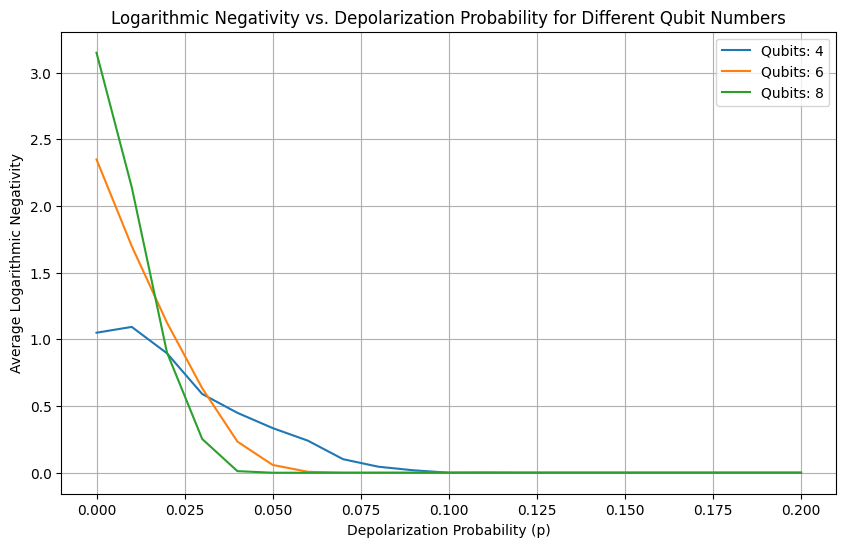

In [11]:
# Variables

p_values = np.arange(0, 0.21, 0.01)
q_values = np.arange(2, 5, 1)

results = {}

num_runs = 20
# average_log_negv_values = []
# average_negv_values = []

for q in q_values:
    results[q] = {}
    for p in p_values:
        log_negv_runs = []
        negv_runs = []
        for i in range(num_runs):
            circuit = random_brickwork_circuit(q * 2)

            # Create depolarizing error channel

            depo_err_chan = depolarizing_error(p, 1)

            # Noise model

            noise_model = NoiseModel()
            noise_model.add_basis_gates(['unitary'])
            noise_model.add_all_qubit_quantum_error(depo_err_chan, ["dp"])
            sim_noise = AerSimulator(noise_model=noise_model)
            
            # # Optimization
            
            # passmanager = generate_preset_pass_manager(optimization_level=3, backend=sim_noise)
            # circ_tnoise = passmanager.run(circuit)

            # Job

            job = sim_noise.run(circuit)
            result = job.result().data()
            dm = result.get('density_matrix')

            # Calculate negativity

            log_negv = calculate_log_negativity(dm, list(range(int(q))))

            # rho = DensityMatrix(dm)
            # negv_array = list(range(int(q)))
            # negv = negativity(rho, negv_array)
            # log_negv = math.log(2 * negv + 1, 2)

            log_negv_runs.append(log_negv)
            # negv_runs.append(negv)

            # print(rho)
            # print(log_negv)

        # Store average negativity
        
        results[q][p] = np.mean(log_negv_runs)

        # average_log_negv_values.append(np.mean(log_negv_runs))
        # average_negv_values.append(np.mean(negv_runs))

# # Plotting logarithmic negativity

# plt.figure(figsize=(8, 6))
# plt.plot(p_values, average_log_negv_values, marker='o', label='log_negv vs p')
# plt.xlabel('Depolarizing Error Probability (p)')
# plt.ylabel('Average logarithmic negativity')
# plt.title('Average logarithmic negativity as a Function of Depolarizing Probability')
# plt.grid(True)
# plt.legend()
# plt.show()

# Plot results
plt.figure(figsize=(10, 6))
for q, p_negv in results.items():
    p_values = list(p_negv.keys())
    avg_log_negv_values = list(p_negv.values())
    plt.plot(p_values, avg_log_negv_values, label=f'Qubits: {2*q}')

plt.xlabel("Depolarization Probability (p)")
plt.ylabel("Average Logarithmic Negativity")
plt.title("Logarithmic Negativity vs. Depolarization Probability for Different Qubit Numbers")
plt.legend()
plt.grid()
plt.show()

In [8]:
# plt.figure(figsize=(8, 6))
# plt.plot(p_values, average_negv_values, marker='o', label='negv vs p')
# plt.xlabel('Depolarizing Error Probability (p)')
# plt.ylabel('Average negativity')
# plt.title('Average negativity as a Function of Depolarizing Probability')
# plt.grid(True)
# plt.legend()
# plt.show()